In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.integrate import trapezoid as trapz


# Configuration
# put here the path for your repository root (where you have the data and src folders)
REPO_ROOT = None # "/path/to/your/repo/root"
if REPO_ROOT is None:
    REPO_ROOT = os.getcwd()
    REPO_ROOT = REPO_ROOT.replace("/src/analysis", "")

# put here the path for yout dsi output txt file
input_file = f"{REPO_ROOT}/data/hcp/dsi_outputs/bmi_age_sex.fdr_dist.values.txt"
# put here the path where you want to save the outputs of the analysis 
output_dir = f"{REPO_ROOT}/data/hcp/dsi_outputs/advanced_metrics"
output_dir = Path(output_dir)
output_dir.mkdir(exist_ok=True)

fdr_threshold = 0.05  # threshold for significant findings (false discovery rate)
long_threshold = 80   # threshold for long-range robustness analysis

# Load Data

In [24]:
df = pd.read_csv(input_file, sep="\t")

df = df.rename(columns={
    "#track_inc_null": "track_inc_null",
    "#track_dec_null": "track_dec_null",
    "#track_inc": "track_inc",
    "#track_dec": "track_dec"
})

cols = [
    "voxel_dis",
    "fdr_inc",
    "fdr_dec",
    "track_inc_null",
    "track_dec_null",
    "track_inc",
    "track_dec"
]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["voxel_dis"]).reset_index(drop=True)

# Derived Metrics

Knowing that the following columns represent:
* track_inc: Number of increasing tracks detected
* track_dec: Number of decreasing tracks detected
* track_inc_null: Number of increasing tracks in null permutations
* track_dec_null: Number of decreasing tracks in null permutations
* voxel_dis: Tract length threshold (voxel distance)

We propose here to calculate more metrics based on them in order to get further statistical representation. If the feedback from the doctors is that they make sense we can add them on the automated reporting journey.

In [25]:
# avoid division by zero in later calculations
epsilon = 1e-6

### Observed-minus-null Difference

Measures signal strength above statistical noise using the absolute difference between observed connectometry findings and expected null/random findings.

Interpretation:
* Large positive values indicate stronger evidence that detected pathways are not due to random chance.
* Values near zero suggest little separation between observed and null distributions.

In [26]:
# Observed-minus-null
df["inc_observed_minus_null"] = df["track_inc"] - df["track_inc_null"]
df["dec_observed_minus_null"] = df["track_dec"] - df["track_dec_null"]

### Dominance Ratio

Measures how dominant the observed tracks are relative to null tracks.

We know the null tracks represent tracks obtained from permutation/randomization, so the ratrio compares real signal vs random signal.

Interpretation:
* bigger than 1: the detected pathways are stronger than expected by chance
* aprox. 1: observed similar to the expected by change
* smaller than 1: the observed signal is weaker than random expectation, which normally means weak or noisy signal

In [27]:
# Dominance ratio: observed / null
df["inc_dominance_ratio"] = df["track_inc"] / (df["track_inc_null"] + 1)
df["dec_dominance_ratio"] = df["track_dec"] / (df["track_dec_null"] + 1)

### Separation Score

Measures normalized separation between observed and null distributions.

Interpretation:
* Higher values indicate: stronger statistical separation and cleaner signal detection.
* Lower values indicate: weak statistical separation and noisy signal detection.
* Values near zero suggest that observed findings are similar to the null distribution, indicating little evidence above random chance.
* Negative values indicate that null findings exceed observed findings, suggesting unstable or non-significant signal.

In [28]:
# Separation score: normalized observed-null difference
df["inc_separation_score"] = (
    df["track_inc"] - df["track_inc_null"]
) / (df["track_inc_null"] + 1)

df["dec_separation_score"] = (
    df["track_dec"] - df["track_dec_null"]
) / (df["track_dec_null"] + 1)

### Persistence Curves

Measures how persistent the connectometry signal remains across increasing tract-length thresholds. Assumes that longer tract thresholds are more stringent.

Assumes that as tract-length thresholds increase, the analysis becomes more selective because only longer and more spatially consistent pathways remain detectable. Pathways that remain significant at larger thresholds are considered more robust and biologically plausible.

Interpretation
* 1: strongest persistence,
* 0: disappeared signal.

In [29]:
# Normalized persistence curves
df["inc_persistence"] = df["track_inc"] / (df["track_inc"].max() + epsilon)
df["dec_persistence"] = df["track_dec"] / (df["track_dec"].max() + epsilon)

### Stability Slope

Measures how rapidly significant tracks disappear as tract-length thresholds increase.

Interpretation
* ++1: unexpected increase
* 0: dstable persistence
* --1: rapid signal decay

Assuming that a stable connectometry signal should decrease slowly and persist across thresholds. Rapid signal decay (strongly negative) may indicate unstable findings and noisy signal.

In [30]:
# Stability slope: how fast tracks disappear as threshold increases
df["inc_stability_slope"] = np.gradient(df["track_inc"], df["voxel_dis"])
df["dec_stability_slope"] = np.gradient(df["track_dec"], df["voxel_dis"])

## Global Summary Metrics

### AUC
Summarizes the overall behavior of a metric across tract-length thresholds. Instead of evaluating a single threshold independently, AUC captures the cumulative signal across the entire threshold range.

Interpretation:
* Higher AUC values indicate stronger or more persistent signal across thresholds.
* Lower AUC values indicate weaker or less stable signal across thresholds.

In [31]:
# In this case it accepts any x and y
# but we will use it to compute AUC of the persistence curves
def auc(x, y):
    return trapz(y, x)

### First Significant Threshold

Identifies the first tract-length threshold where the False Discovery Rate (FDR) becomes statistically significant. It filters rows where FDR is below the predefined significance threshold and selects the smallest corresponding tract-length threshold.

Interpretation:
* Smaller thresholds indicate that significance appears earlier in the analysis.
* Larger thresholds indicate that significance only emerges under stricter pathway-length constraints.
* None indicates that no statistically significant threshold was detected.

We could use for detecting the onset of significant findings, comparing robustness between connectometry analyses, identifying sensitivity to tract-length constraints.

In [32]:
def first_significant_threshold(fdr_col):
    sig = df[df[fdr_col] <= fdr_threshold]
    if sig.empty:
        return None
    return int(sig["voxel_dis"].min())

In [33]:
# Safe max function to handle missing columns
def safe_max(col):
    return float(df[col].max()) if col in df else np.nan

In [34]:
metrics = {
    "increase": {
        "first_significant_threshold": first_significant_threshold("fdr_inc"),
        "min_fdr": df["fdr_inc"].min(),
        "voxel_at_min_fdr": int(df.loc[df["fdr_inc"].idxmin(), "voxel_dis"]),
        "observed_auc": auc(df["voxel_dis"], df["track_inc"]),
        "null_auc": auc(df["voxel_dis"], df["track_inc_null"]),
        "auc_ratio_observed_to_null": auc(df["voxel_dis"], df["track_inc"]) / (auc(df["voxel_dis"], df["track_inc_null"]) + 1),
        "max_tracks": df["track_inc"].max(),
        "max_null_tracks": df["track_inc_null"].max(),
        "max_dominance_ratio": safe_max("inc_dominance_ratio"),
        "max_separation_score": safe_max("inc_separation_score"),
        "mean_persistence": df["inc_persistence"].mean(),
        "long_threshold_tracks": df.loc[df["voxel_dis"] >= long_threshold, "track_inc"].sum()
    },
    "decrease": {
        "first_significant_threshold": first_significant_threshold("fdr_dec"),
        "min_fdr": df["fdr_dec"].min(),
        "voxel_at_min_fdr": int(df.loc[df["fdr_dec"].idxmin(), "voxel_dis"]),
        "observed_auc": auc(df["voxel_dis"], df["track_dec"]),
        "null_auc": auc(df["voxel_dis"], df["track_dec_null"]),
        "auc_ratio_observed_to_null": auc(df["voxel_dis"], df["track_dec"]) / (auc(df["voxel_dis"], df["track_dec_null"]) + 1),
        "max_tracks": df["track_dec"].max(),
        "max_null_tracks": df["track_dec_null"].max(),
        "max_dominance_ratio": safe_max("dec_dominance_ratio"),
        "max_separation_score": safe_max("dec_separation_score"),
        "mean_persistence": df["dec_persistence"].mean(),
        "long_threshold_tracks": df.loc[df["voxel_dis"] >= long_threshold, "track_dec"].sum()
    }
}

summary = pd.DataFrame(metrics).T
summary.to_csv(output_dir / "advanced_summary_metrics.csv")

df.to_csv(output_dir / "advanced_fdr_distribution_metrics.csv", index=False)

print("\n=== ADVANCED CONNECTOMETRY METRICS ===")
print(summary)


=== ADVANCED CONNECTOMETRY METRICS ===
          first_significant_threshold  min_fdr  voxel_at_min_fdr  \
increase                          NaN      1.0              20.0   
decrease                         20.0      0.0              27.0   

          observed_auc  null_auc  auc_ratio_observed_to_null  max_tracks  \
increase           0.0       0.0                         0.0         0.0   
decrease         586.0       0.0                       586.0       278.0   

          max_null_tracks  max_dominance_ratio  max_separation_score  \
increase              0.0                  0.0                   0.0   
decrease              0.0                278.0                 278.0   

          mean_persistence  long_threshold_tracks  
increase          0.000000                    0.0  
decrease          0.014569                    0.0  


In [35]:
# Automatic Interpretation
# Can be use for automated reporting
inc_sig = metrics["increase"]["first_significant_threshold"]
dec_sig = metrics["decrease"]["first_significant_threshold"]

if dec_sig is not None and inc_sig is None:
    main_interpretation = (
        "The connectometry result is dominated by negative/decrease associations. "
        "This suggests that higher values of the study variable are associated with "
        "lower local connectome / QA along coherent white matter pathways."
    )
elif inc_sig is not None and dec_sig is None:
    main_interpretation = (
        "The connectometry result is dominated by positive/increase associations. "
        "This suggests that higher values of the study variable are associated with "
        "higher local connectome / QA along coherent white matter pathways."
    )
elif inc_sig is not None and dec_sig is not None:
    main_interpretation = (
        "Both positive/increase and negative/decrease associations reached the FDR threshold. "
        "Both tractograms should be interpreted separately."
    )
else:
    main_interpretation = (
        "No direction reached the selected FDR threshold. "
        "The result may not be statistically robust under the current parameters."
    )

print("\nInterpretation:")
print(main_interpretation)


Interpretation:
The connectometry result is dominated by negative/decrease associations. This suggests that higher values of the study variable are associated with lower local connectome / QA along coherent white matter pathways.


In [36]:
def save_plot(filename):
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=300)
    plt.show()

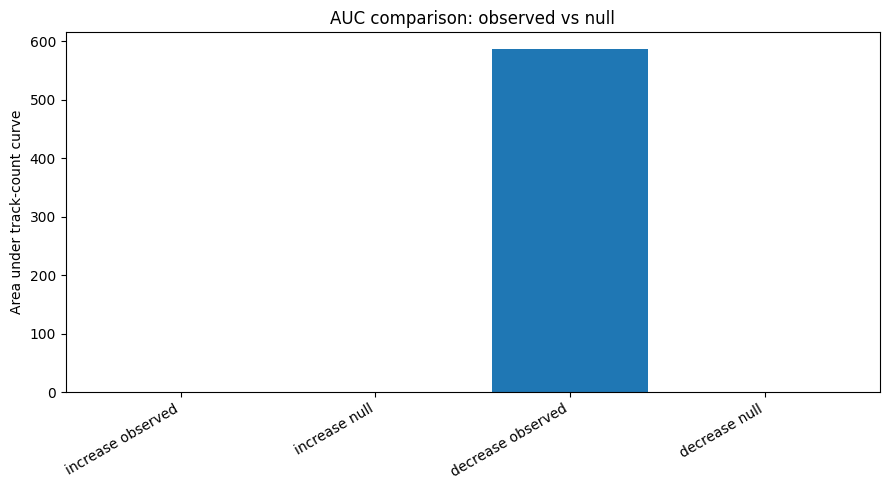

In [37]:
auc_plot = pd.DataFrame({
    "direction": ["increase observed", "increase null", "decrease observed", "decrease null"],
    "auc": [
        metrics["increase"]["observed_auc"],
        metrics["increase"]["null_auc"],
        metrics["decrease"]["observed_auc"],
        metrics["decrease"]["null_auc"]
    ]
})

plt.figure(figsize=(9, 5))
plt.bar(auc_plot["direction"], auc_plot["auc"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Area under track-count curve")
plt.title("AUC comparison: observed vs null")
save_plot("01_auc_observed_vs_null.png")

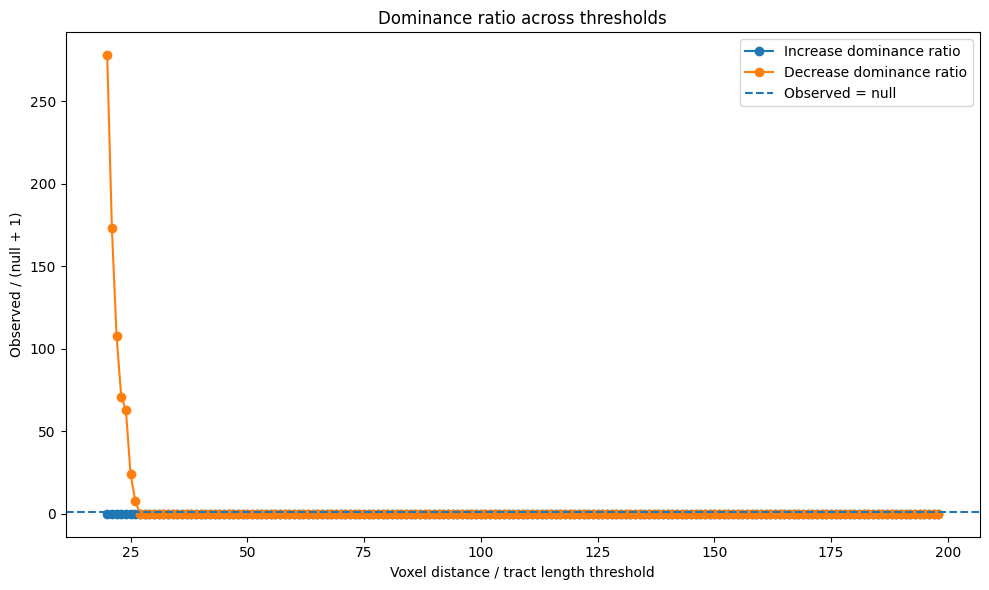

In [38]:
# ============================================================
# PLOT 2: DOMINANCE RATIO
# ============================================================

plt.figure(figsize=(10, 6))
plt.plot(df["voxel_dis"], df["inc_dominance_ratio"], marker="o", label="Increase dominance ratio")
plt.plot(df["voxel_dis"], df["dec_dominance_ratio"], marker="o", label="Decrease dominance ratio")
plt.axhline(1, linestyle="--", label="Observed = null")
plt.xlabel("Voxel distance / tract length threshold")
plt.ylabel("Observed / (null + 1)")
plt.title("Dominance ratio across thresholds")
plt.legend()
save_plot("02_dominance_ratio.png")

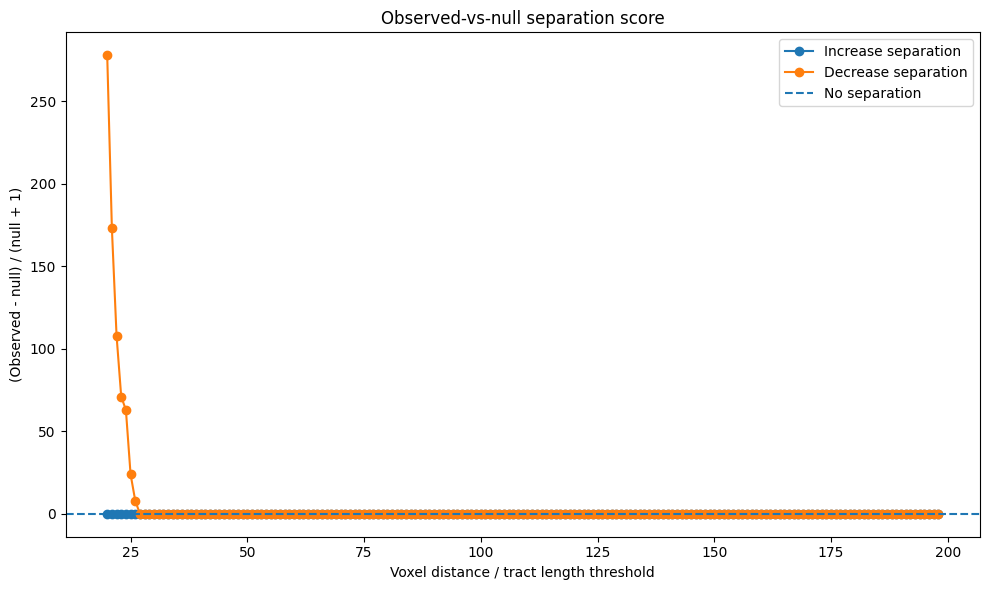

In [39]:
# ============================================================
# PLOT 3: SEPARATION SCORE
# ============================================================

plt.figure(figsize=(10, 6))
plt.plot(df["voxel_dis"], df["inc_separation_score"], marker="o", label="Increase separation")
plt.plot(df["voxel_dis"], df["dec_separation_score"], marker="o", label="Decrease separation")
plt.axhline(0, linestyle="--", label="No separation")
plt.xlabel("Voxel distance / tract length threshold")
plt.ylabel("(Observed - null) / (null + 1)")
plt.title("Observed-vs-null separation score")
plt.legend()
save_plot("03_separation_score.png")

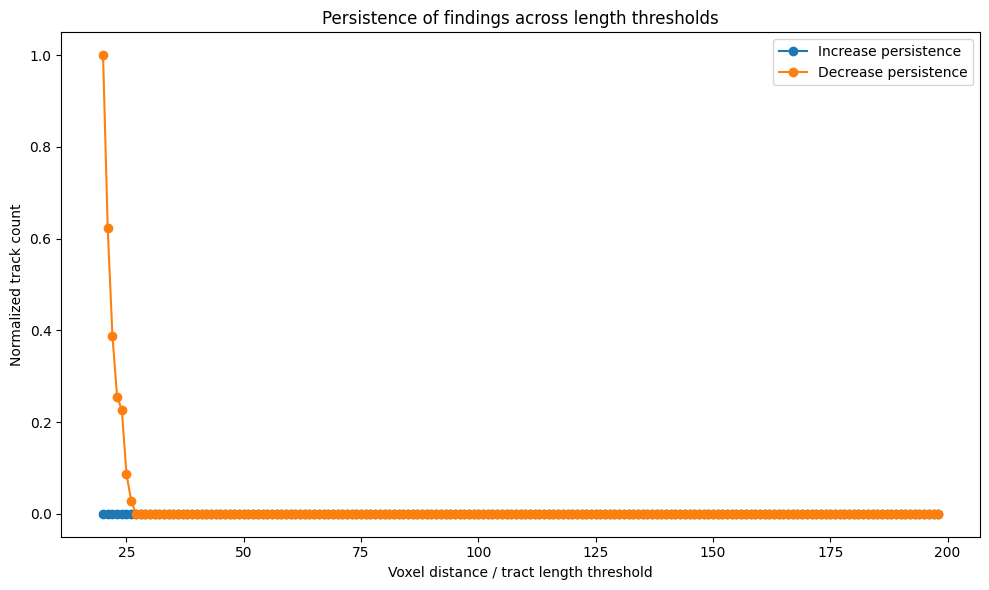

In [40]:
# ============================================================
# PLOT 4: PERSISTENCE CURVE
# ============================================================

plt.figure(figsize=(10, 6))
plt.plot(df["voxel_dis"], df["inc_persistence"], marker="o", label="Increase persistence")
plt.plot(df["voxel_dis"], df["dec_persistence"], marker="o", label="Decrease persistence")
plt.xlabel("Voxel distance / tract length threshold")
plt.ylabel("Normalized track count")
plt.title("Persistence of findings across length thresholds")
plt.legend()
save_plot("04_persistence_curve.png")


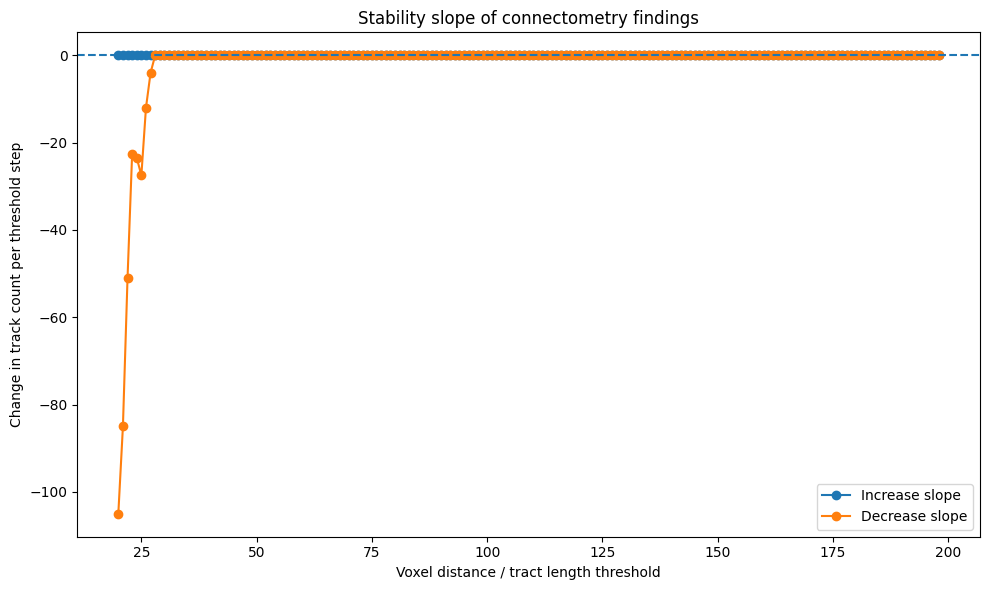

In [41]:
# ============================================================
# PLOT 5: STABILITY SLOPE
# ============================================================

plt.figure(figsize=(10, 6))
plt.plot(df["voxel_dis"], df["inc_stability_slope"], marker="o", label="Increase slope")
plt.plot(df["voxel_dis"], df["dec_stability_slope"], marker="o", label="Decrease slope")
plt.axhline(0, linestyle="--")
plt.xlabel("Voxel distance / tract length threshold")
plt.ylabel("Change in track count per threshold step")
plt.title("Stability slope of connectometry findings")
plt.legend()
save_plot("05_stability_slope.png")

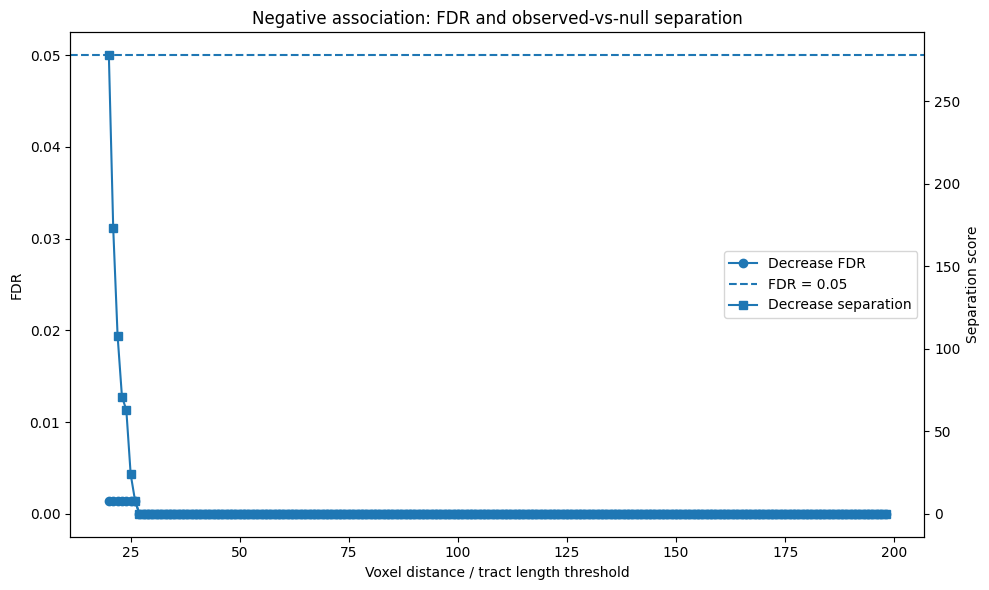

In [42]:
# ============================================================
# PLOT 6: FDR + SEPARATION TOGETHER
# ============================================================

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(df["voxel_dis"], df["fdr_dec"], marker="o", label="Decrease FDR")
ax1.axhline(fdr_threshold, linestyle="--", label=f"FDR = {fdr_threshold}")
ax1.set_xlabel("Voxel distance / tract length threshold")
ax1.set_ylabel("FDR")

ax2 = ax1.twinx()
ax2.plot(df["voxel_dis"], df["dec_separation_score"], marker="s", label="Decrease separation")
ax2.set_ylabel("Separation score")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.title("Negative association: FDR and observed-vs-null separation")
plt.tight_layout()
plt.savefig(output_dir / "06_negative_fdr_and_separation.png", dpi=300)
plt.show()

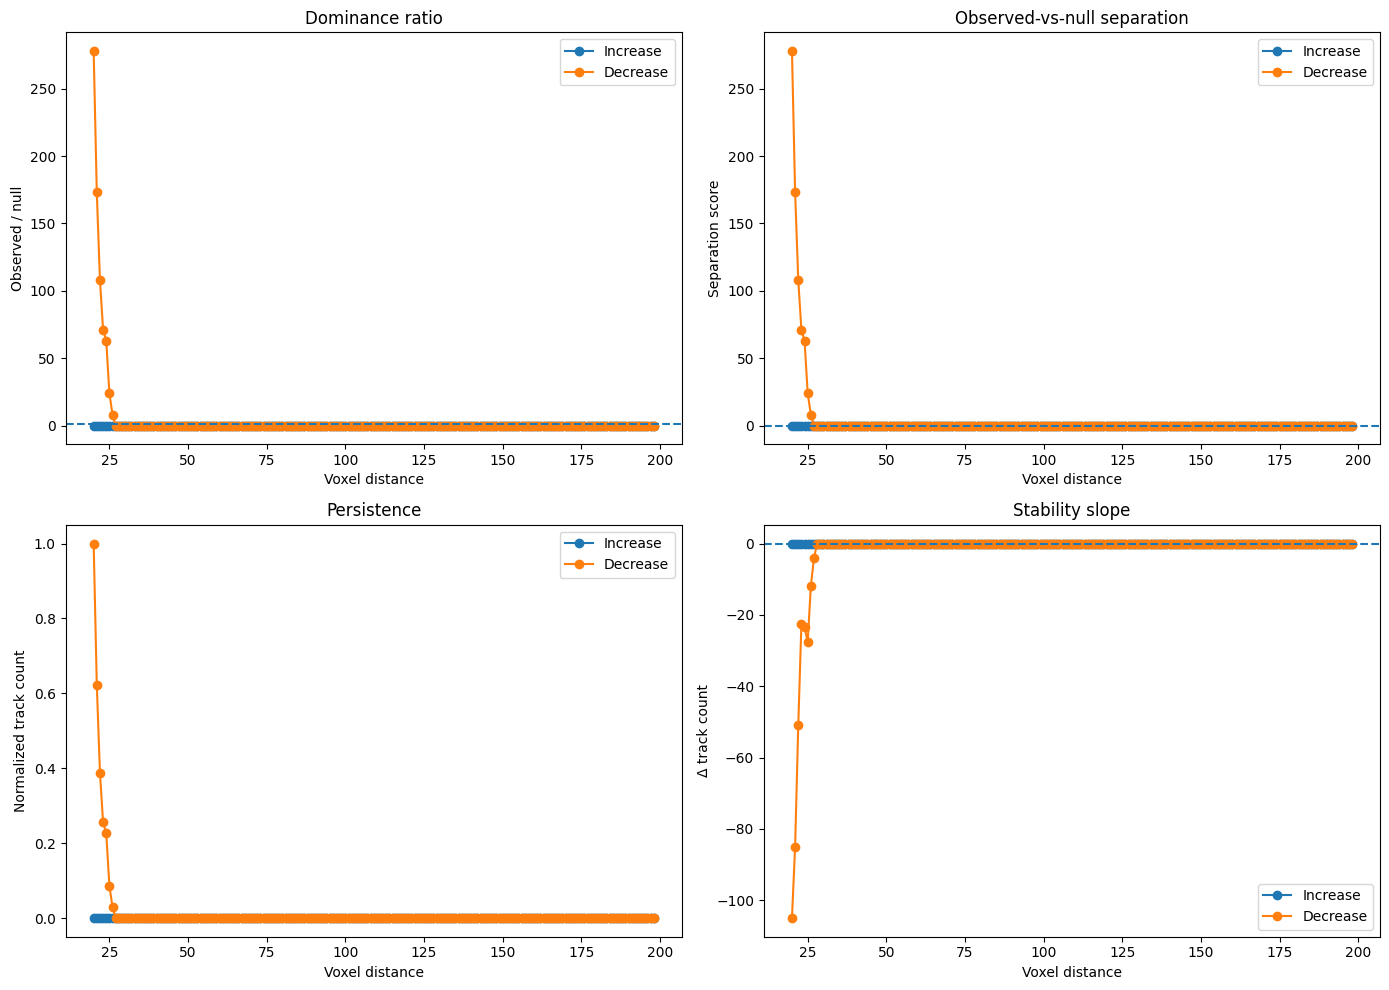

In [43]:

# ============================================================
# PLOT 7: ADVANCED SUMMARY PANEL
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(df["voxel_dis"], df["inc_dominance_ratio"], marker="o", label="Increase")
axes[0, 0].plot(df["voxel_dis"], df["dec_dominance_ratio"], marker="o", label="Decrease")
axes[0, 0].axhline(1, linestyle="--")
axes[0, 0].set_title("Dominance ratio")
axes[0, 0].set_xlabel("Voxel distance")
axes[0, 0].set_ylabel("Observed / null")
axes[0, 0].legend()

axes[0, 1].plot(df["voxel_dis"], df["inc_separation_score"], marker="o", label="Increase")
axes[0, 1].plot(df["voxel_dis"], df["dec_separation_score"], marker="o", label="Decrease")
axes[0, 1].axhline(0, linestyle="--")
axes[0, 1].set_title("Observed-vs-null separation")
axes[0, 1].set_xlabel("Voxel distance")
axes[0, 1].set_ylabel("Separation score")
axes[0, 1].legend()

axes[1, 0].plot(df["voxel_dis"], df["inc_persistence"], marker="o", label="Increase")
axes[1, 0].plot(df["voxel_dis"], df["dec_persistence"], marker="o", label="Decrease")
axes[1, 0].set_title("Persistence")
axes[1, 0].set_xlabel("Voxel distance")
axes[1, 0].set_ylabel("Normalized track count")
axes[1, 0].legend()

axes[1, 1].plot(df["voxel_dis"], df["inc_stability_slope"], marker="o", label="Increase")
axes[1, 1].plot(df["voxel_dis"], df["dec_stability_slope"], marker="o", label="Decrease")
axes[1, 1].axhline(0, linestyle="--")
axes[1, 1].set_title("Stability slope")
axes[1, 1].set_xlabel("Voxel distance")
axes[1, 1].set_ylabel("Δ track count")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(output_dir / "07_advanced_summary_panel.png", dpi=300)
plt.show()


In [44]:

# ============================================================
# SAVE TEXT REPORT
# ============================================================

report = f"""
ADVANCED CONNECTOMETRY POST-PROCESSING REPORT
============================================

Input file:
{input_file}

FDR threshold:
{fdr_threshold}

Long-threshold cutoff:
{long_threshold}

MAIN INTERPRETATION
-------------------
{main_interpretation}

INCREASE / POSITIVE ASSOCIATION
-------------------------------
First significant threshold:
{metrics["increase"]["first_significant_threshold"]}

Minimum FDR:
{metrics["increase"]["min_fdr"]}

Voxel distance at minimum FDR:
{metrics["increase"]["voxel_at_min_fdr"]}

Observed AUC:
{metrics["increase"]["observed_auc"]}

Null AUC:
{metrics["increase"]["null_auc"]}

Observed/null AUC ratio:
{metrics["increase"]["auc_ratio_observed_to_null"]}

Maximum observed tracks:
{metrics["increase"]["max_tracks"]}

Maximum null tracks:
{metrics["increase"]["max_null_tracks"]}

Maximum dominance ratio:
{metrics["increase"]["max_dominance_ratio"]}

Maximum separation score:
{metrics["increase"]["max_separation_score"]}

Mean persistence:
{metrics["increase"]["mean_persistence"]}

Long-threshold track burden:
{metrics["increase"]["long_threshold_tracks"]}


DECREASE / NEGATIVE ASSOCIATION
-------------------------------
First significant threshold:
{metrics["decrease"]["first_significant_threshold"]}

Minimum FDR:
{metrics["decrease"]["min_fdr"]}

Voxel distance at minimum FDR:
{metrics["decrease"]["voxel_at_min_fdr"]}

Observed AUC:
{metrics["decrease"]["observed_auc"]}

Null AUC:
{metrics["decrease"]["null_auc"]}

Observed/null AUC ratio:
{metrics["decrease"]["auc_ratio_observed_to_null"]}

Maximum observed tracks:
{metrics["decrease"]["max_tracks"]}

Maximum null tracks:
{metrics["decrease"]["max_null_tracks"]}

Maximum dominance ratio:
{metrics["decrease"]["max_dominance_ratio"]}

Maximum separation score:
{metrics["decrease"]["max_separation_score"]}

Mean persistence:
{metrics["decrease"]["mean_persistence"]}

Long-threshold track burden:
{metrics["decrease"]["long_threshold_tracks"]}


METRIC DEFINITIONS
------------------
AUC:
Area under the track-count curve. Higher values indicate a larger and more persistent tract-level effect.

Dominance ratio:
Observed tracks divided by null tracks. Values above 1 indicate that observed findings exceed permutation-based null findings.

Separation score:
Observed-minus-null normalized by null. Higher values indicate stronger separation from random permutations.

Persistence:
Normalized track count across length thresholds. A slower decay indicates more robust long-range findings.

Stability slope:
Rate at which tracks disappear as the length threshold increases. A flatter slope indicates more stable findings.

Long-threshold burden:
Number of observed tracks surviving beyond the selected long-distance threshold.
"""

with open(output_dir / "advanced_interpretation_report.txt", "w") as f:
    f.write(report)

print("\nAdvanced post-processing complete.")
print(f"Outputs saved to: {output_dir}")


Advanced post-processing complete.
Outputs saved to: /Users/bandeiramonica/Downloads/BMIA/BMIA_IMCV_Connectometry/data/hcp/dsi_outputs/advanced_metrics
